# Plotmap demo

`plotmap` allows for easy, flexible, and publication-quality plotting of spatial data.

In [1]:
import sys

sys.path.append('../')

In [2]:
import cdsapi
import xarray
from cartopy import crs as ccrs

import plotmap


For this demo, let's download some ERA5 data to plot over Australia.

In [3]:
cds = cdsapi.Client()

In [4]:
cds.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'format': 'netcdf',
        'variable': ['2m_temperature', 'convective_available_potential_energy',
                     '2m_dewpoint_temperature', 'mean_sea_level_pressure', 'lsm'],
        'year': '2020',
        'month': '01',
        'day': '20',
        'time': '00:00',
        'area': [-10, 112, -44, 154],
        'grid': [0.25, 0.25],
    },
    'demo_data.nc',
)


2026-02-25 12:29:53,886 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-02-25 12:29:53,887 INFO Request ID is 4e454acf-cdc3-4fca-a8c2-0f377889e490
2026-02-25 12:29:54,194 INFO status has been updated to accepted
2026-02-25 12:30:17,283 INFO status has been updated to successful


'demo_data.nc'

In [5]:
dat = xarray.open_dataset('demo_data.nc').isel(valid_time=0)
display(dat)

<xarray.Dataset> Size: 466kB
Dimensions:     (latitude: 137, longitude: 169)
Coordinates:
  * latitude    (latitude) float64 1kB -10.0 -10.25 -10.5 ... -43.5 -43.75 -44.0
  * longitude   (longitude) float64 1kB 112.0 112.2 112.5 ... 153.5 153.8 154.0
    number      int64 8B ...
    valid_time  datetime64[ns] 8B 2020-01-20
    expver      <U4 16B ...
Data variables:
    t2m         (latitude, longitude) float32 93kB ...
    cape        (latitude, longitude) float32 93kB ...
    d2m         (latitude, longitude) float32 93kB ...
    msl         (latitude, longitude) float32 93kB ...
    lsm         (latitude, longitude) float32 93kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-25T00:54 GRIB to CDM+CF via cfgrib-0.9.1...

The main function is `plotmap.plot_map`. At minimum it takes spatial data to plot as an `xarray.DataArray` and produces a map. It will use data attributes for scale names and units.

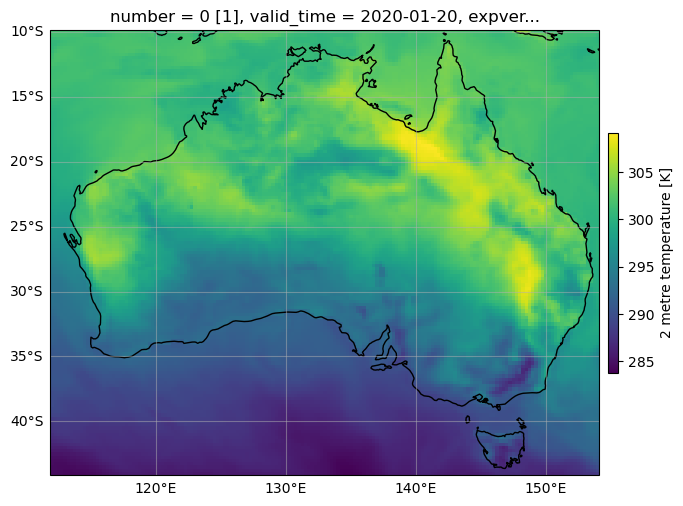

In [6]:
_ = plotmap.plot_map(dat.t2m, figsize=(6,6))

The function can also take a list of inputs to plot into sub-plots. A list of titles gives sub-plot titles.

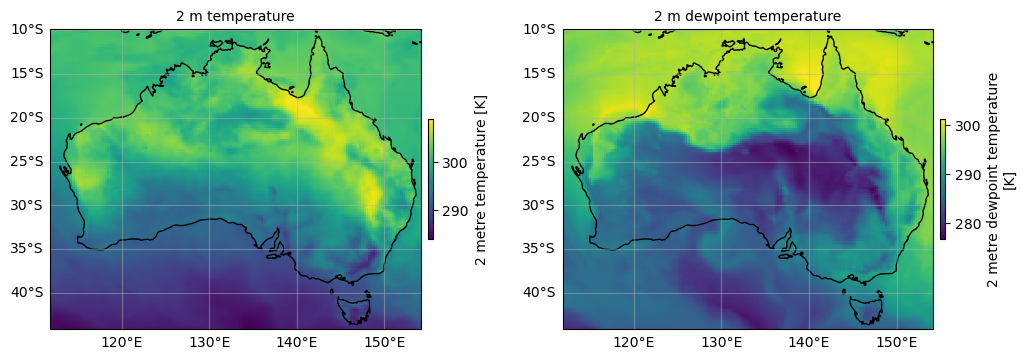

In [7]:
_ = plotmap.plot_map([dat.t2m, dat.d2m], title=['2 m temperature', '2 m dewpoint temperature'], ncols=2, figsize=(10,3))

Let's compare dew-point and dry-bulb temperature for this time:

* To save space, axes can be shared by setting `share_axes=True`. 
* For better comparison scales can be shared using `share_scale=True`. 
* I will select the `Spectral_r` colour map.

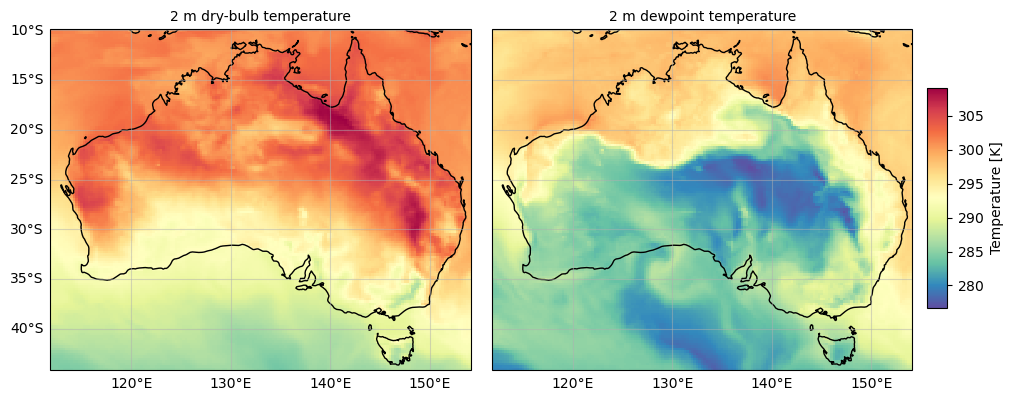

In [8]:
_ = plotmap.plot_map(
    [dat.t2m, dat.d2m],
    title=['2 m dry-bulb temperature', '2 m dewpoint temperature'],
    ncols=2,
    figsize=(10, 4),
    share_scale=True,
    share_axes=True,
    scale_label='Temperature [K]',
    cmap='Spectral_r',
)

We can combine plots in flexible ways:

* Use `wspace` and `hspace` to control horizontal (width) and vertical (height) spacing, respectively.
* Inset the colour bars (`cbar_inset=True`) and make them horizontal (`cbar_orientation='horizontal'`).
* Add letter labels inset into the top corner of each plot (`title_inset=True` and `letter_labels=True`).
* Remove the grid (`grid=False`) and set missing values to white (`nan_colour='white'`).

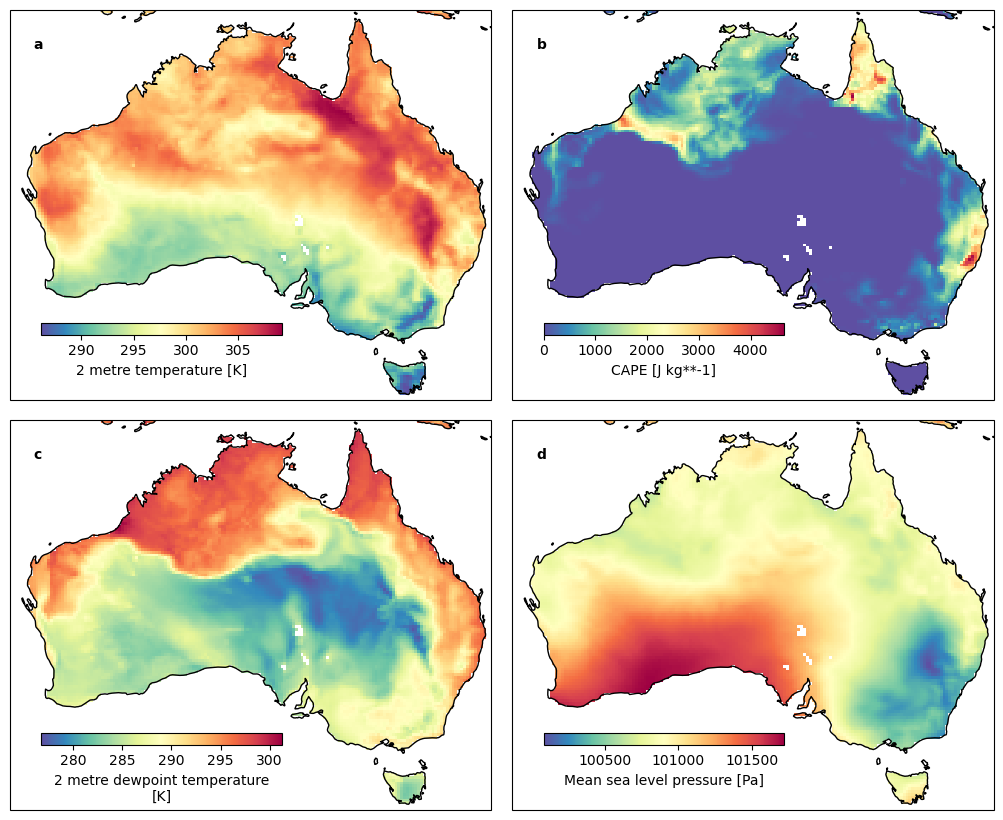

In [9]:
dat_land = dat.where(dat.lsm > 0.5)
dat_land.cape.attrs['long_name'] = 'CAPE'

_ = plotmap.plot_map(
    [dat_land.t2m, dat_land.cape, dat_land.d2m, dat_land.msl],
    ncols=2,
    nrows=2,
    figsize=(10, 8),
    wspace=0.01,
    hspace=0.05,
    cmap='Spectral_r',
    letter_labels=True,
    cbar_inset=True,
    cbar_orientation='horizontal',
    title_inset=True,
    nan_colour='white',
    grid=False,
)

Map projections are set using `dat_proj` to specify the data projection and `disp_proj` to specify which projection to use for display. Both should be from the [Cartopy list](https://cartopy.readthedocs.io/v0.25.0.post2/reference/projections.html) and both default to lat/long (Plate Carrée).

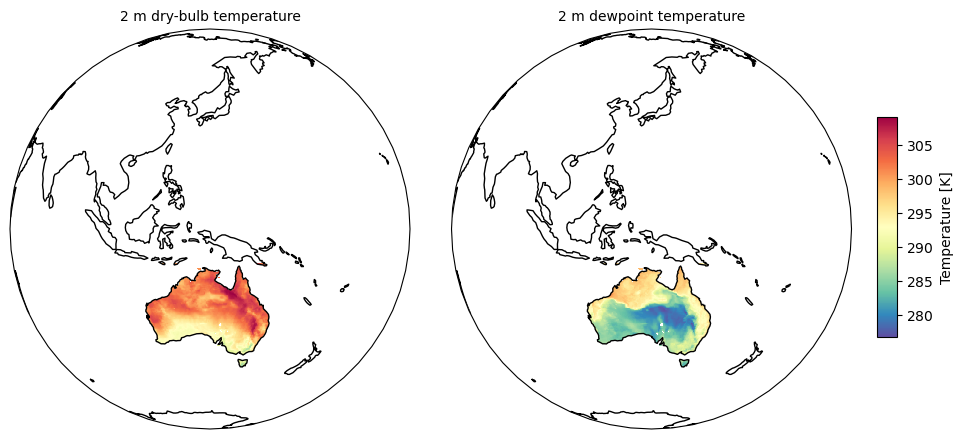

In [ ]:
axs = plotmap.plot_map(
    [dat_land.t2m, dat_land.d2m],
    title=['2 m dry-bulb temperature', '2 m dewpoint temperature'],
    ncols=2,
    figsize=(10, 4),
    share_scale=True,
    share_axes=True,
    scale_label='Temperature [K]',
    cmap='Spectral_r',
    disp_proj=ccrs.Orthographic(central_longitude=134),
    grid=False,
    set_global=True,
    nan_colour='white',
)